# Import libraries

In [ ]:
# Import libraries
import time

# Data manipulation and visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Bayesian optimization
from hyperopt import STATUS_OK, Trials, fmin, hp, space_eval, tpe

# Scikit-learn preprocessing, models, and evaluation
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

import shap

# Helper function

In [2]:
# Load reusable preprocessing and analysis functions
%run "../src/helper_functions.py"


# Load data

In [3]:
# Load the original dataset
df = pd.read_csv('../data/bank-additional-full.csv', sep=';')


In [4]:
# Preview the first records of the dataset
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
# Inspect column names, data types, and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [6]:
# Check the number of rows and columns.
df.shape


(41188, 21)

# Pre-preprocessing

In [7]:
# Check records that may be inconsistent before transforming pdays
suspicious_records = df[(df['pdays'] == 999) & (df['previous'] > 0)]
print(len(suspicious_records))


4110


In [8]:
# Remove exact duplicate records from the working dataset
df = df[~df.duplicated()]


## Analysis of Numerical Features

In [9]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


- The dataset contains **41,176 observations** for each numerical feature, so there are no missing values in these columns at this stage of the analysis.
- The average customer's age is **40.0 years**; the values range from **17 to 98 years**. The median age is **38**, and the mean being slightly higher suggests a moderate right-skew caused by older customers.
- The call `duration` has a median of **180 seconds** and a mean of **258 seconds**, with values from **0 to 4,918 seconds**. The substantially higher mean and maximum indicate a strong right-skew and possible extreme values. This feature should be treated carefully because call duration is known only after a call and may cause target leakage in a predictive model.
- The number of contacts during the campaign (`campaign`) is usually small: the median is **2** and 75% of customers received no more than **3 contacts**. The maximum of **56** indicates a small number of heavily contacted customers and a long right tail.
- `pdays` has a median and third quartile of **999**. In this dataset, **999 is a special code meaning that the customer was not previously contacted**, so it should not be interpreted as 999 actual days. It is better handled as a categorical indicator or transformed into a “previously contacted” feature.
- The previous-campaign contact count (`previous`) is **0 for at least 75% of observations** and has a maximum of **7**. This feature is therefore highly imbalanced and strongly right-skewed.
- The macroeconomic variables have relatively limited ranges. `emp.var.rate` varies from **-3.4 to 1.4**, `cons.price.idx` from **92.201 to 94.767**, `cons.conf.idx` from **-50.8 to -26.9**, `euribor3m` from **0.634 to 5.045**, and `nr.employed` from **4,963.6 to 5,228.1**. Their repeated quartile and maximum values suggest that some observations belong to a small number of economic-period regimes rather than being uniformly distributed.

Overall, the numerical data are complete, but several variables are highly skewed or use special codes. These characteristics should be considered during preprocessing and model building.

In [10]:
# Check whether the cleaned dataset contains any missing values
df.isnull().values.any()


np.False_

There are no columns with null values.

In [11]:
# Create an indicator for previous contact and replace the sentinel value.
df['previously_contacted'] = (df['pdays'] != 999).astype(int)
df['pdays'] = df['pdays'].replace(999, 0)


In [12]:
# Convert the string target to numeric values for correlation analysis.
df_corr = df.copy()
df_corr['y_numeric'] = df_corr['y'].map({'no': 0, 'yes': 1})

# Rank numeric features by the absolute strength of their correlation with the target.
numeric_correlations = (
    df_corr
    .select_dtypes(include='number')
    .corr()['y_numeric']
    .drop('y_numeric')
    .sort_values(key=abs, ascending=False)
    .to_frame('correlation')
)

# Highlight positive and negative correlations.
numeric_correlations.style.background_gradient(
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)


,correlation
duration,0.405297
nr.employed,-0.354669
previously_contacted,0.324910
euribor3m,-0.307740
emp.var.rate,-0.298289
pdays,0.267115
previous,0.230202
cons.price.idx,-0.136134
campaign,-0.066361
cons.conf.idx,0.054802


### Correlation Analysis Conclusion

The strongest positive correlation with the target is observed for `duration` ($r = 0.405$). However, this feature should not be included in the final predictive model because the call duration is known only after the customer has been contacted, which creates target leakage. It can be used only for comparison with models trained after the call.

Among the features available before the call, `previously_contacted` has the strongest positive correlation with subscription (`r = 0.325`). This suggests that customers who were contacted during a previous campaign may be more likely to subscribe. The `pdays` feature also shows a positive correlation (`r = 0.267`), while `previous` has a weaker positive correlation (`r = 0.230`).

Overall, correlation analysis is useful for identifying initial relationships, but it should not be used as the only method for feature selection. Categorical features should be analyzed separately, and model-based feature importance should also be considered.

## Outlier Analysis

In [13]:
# Display the categorical feature names, excluding the target column.
categorical_columns = df.select_dtypes(include='str').columns.drop('y')
categorical_columns


Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='str')

In [14]:
# Calculate potential outliers using the 1.5 x IQR rule for each numeric feature.
numeric_columns = df.select_dtypes(include='number').columns
outlier_summary = []

for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

    outlier_summary.append({
        'feature': column,
        'outlier_count': outlier_count,
        'outlier_percent': round(outlier_count / len(df) * 100, 2),
        'lower_bound': round(lower_bound, 2),
        'upper_bound': round(upper_bound, 2),
    })

# Display features with the highest percentage of potential outliers first.
outlier_summary = (
    pd.DataFrame(outlier_summary)
    .sort_values('outlier_percent', ascending=False)
    .reset_index(drop=True)
)
outlier_summary


,feature,outlier_count,outlier_percent,lower_bound,upper_bound
0,previous,5625,13.66,0.00,0.00
1,duration,2963,7.20,-223.50,644.50
2,campaign,2406,5.84,-2.00,6.00
3,previously_contacted,1515,3.68,0.00,0.00
4,pdays,1500,3.64,0.00,0.00
5,age,468,1.14,9.50,69.50
6,cons.conf.idx,446,1.08,-52.15,-26.95
7,cons.price.idx,0,0.00,91.70,95.37
8,emp.var.rate,0,0.00,-6.60,6.20
9,euribor3m,0,0.00,-4.08,10.39


### Outlier Analysis Conclusion

The IQR method identifies potential outliers in `previous`, `duration`, `campaign`, `pdays`, `previously_contacted`, `age`, and `cons.conf.idx`. These values should not be removed automatically because an IQR flag indicates that a value is statistically unusual, not necessarily incorrect.

- `previous` is strongly right-skewed and mostly equal to zero. Positive values represent customers who were contacted in earlier campaigns and should be retained.
- `pdays` and `previously_contacted` are affected by the special-code transformation. The zero values in `pdays` represent customers who were not contacted previously, so they are valid and should not be treated as outliers.
- `campaign` contains some customers with many contacts. These observations may be unusual, but they are possible real cases and should be retained initially.
- `age` has a small number of high-age observations. The values are plausible, so they should be kept unless a domain rule identifies them as invalid.
- `cons.conf.idx` has a small number of statistically unusual values, but they remain within the possible range of the feature and should not be removed.
- `duration` is right-skewed and has extreme values, but it is excluded from the final model because it causes target leakage. It may be retained only for exploratory analysis or comparison models.

Therefore, no rows are removed based only on the IQR rule. The models will use the cleaned and engineered features, while the outlier analysis is kept for documentation and further experimentation.


## Analysis of Categorical Features

In [15]:
categorical_columns = df.select_dtypes(include='str').columns.drop('y')
categorical_columns


Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='str')

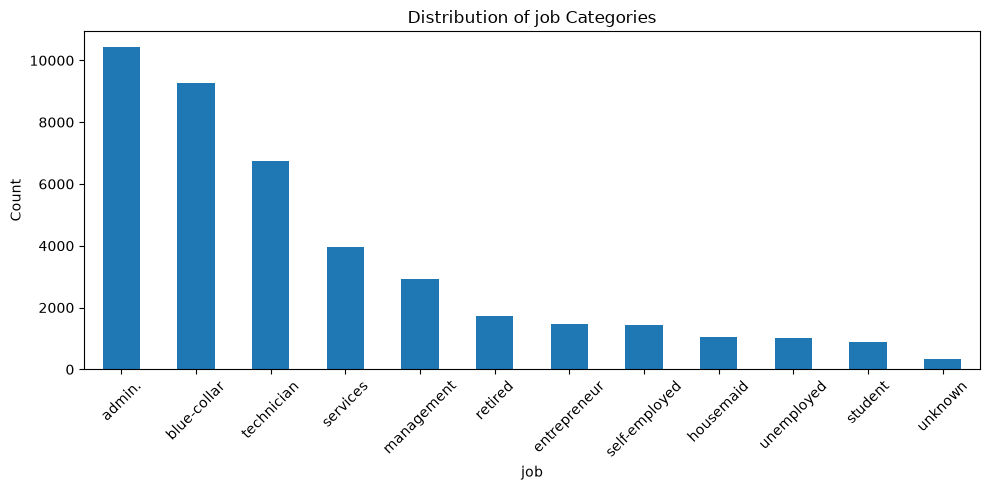

In [16]:
# Plot the frequency of job categories.
plot_categorical_distribution(df, 'job')


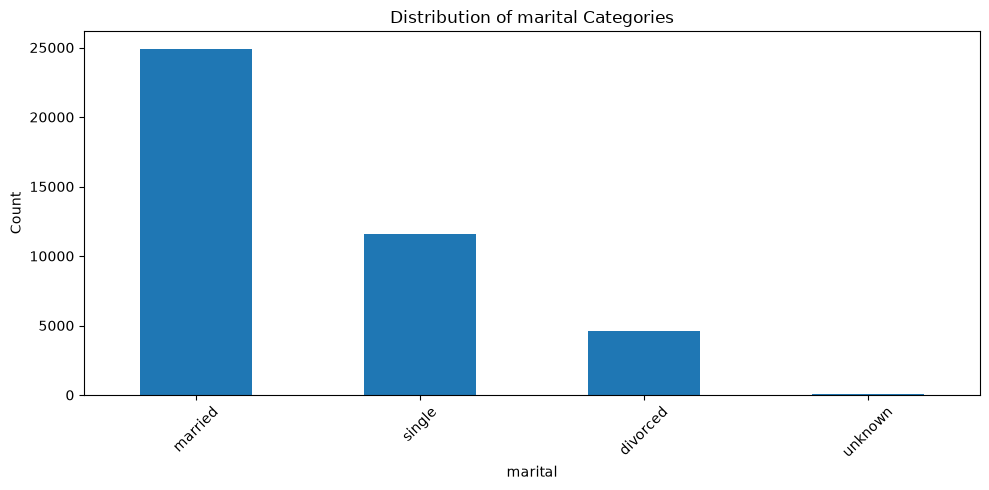

In [17]:
# Plot the frequency of marital-status categories.
plot_categorical_distribution(df, 'marital')


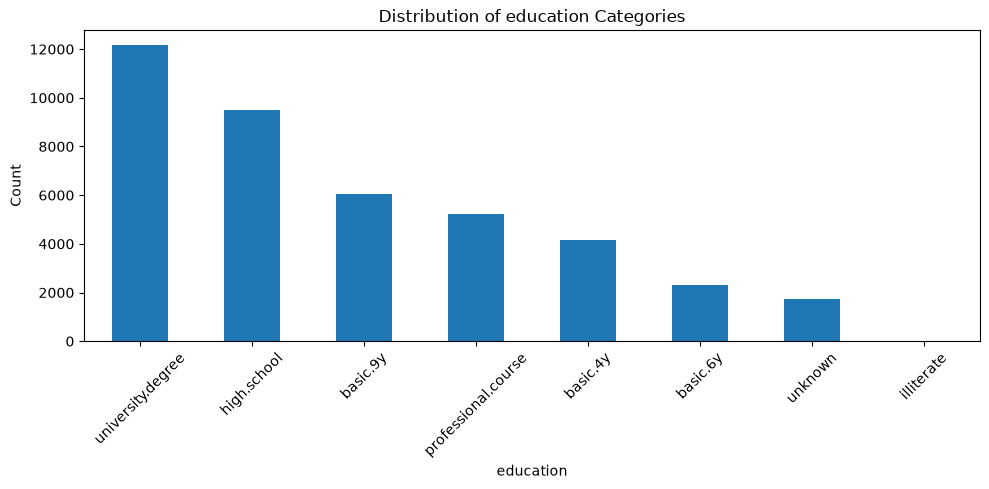

In [18]:
# Plot the frequency of education categories.
plot_categorical_distribution(df, 'education')


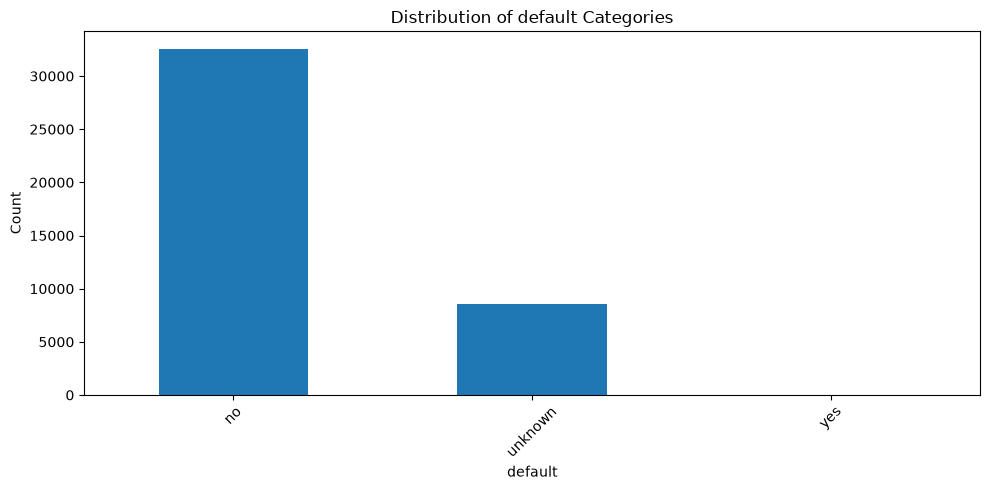

In [19]:
# Plot the frequency of default-status categories.
plot_categorical_distribution(df, 'default')


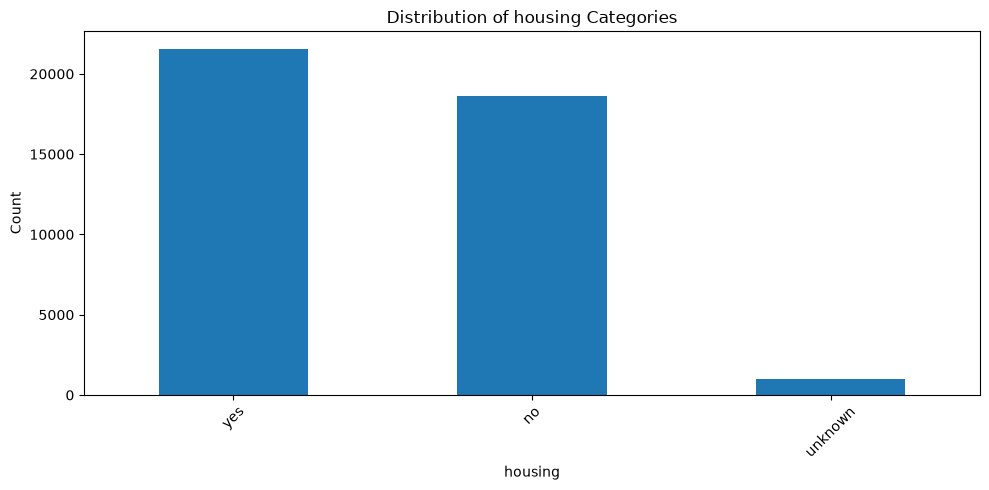

In [20]:
# Plot the frequency of housing-loan categories.
plot_categorical_distribution(df, 'housing')


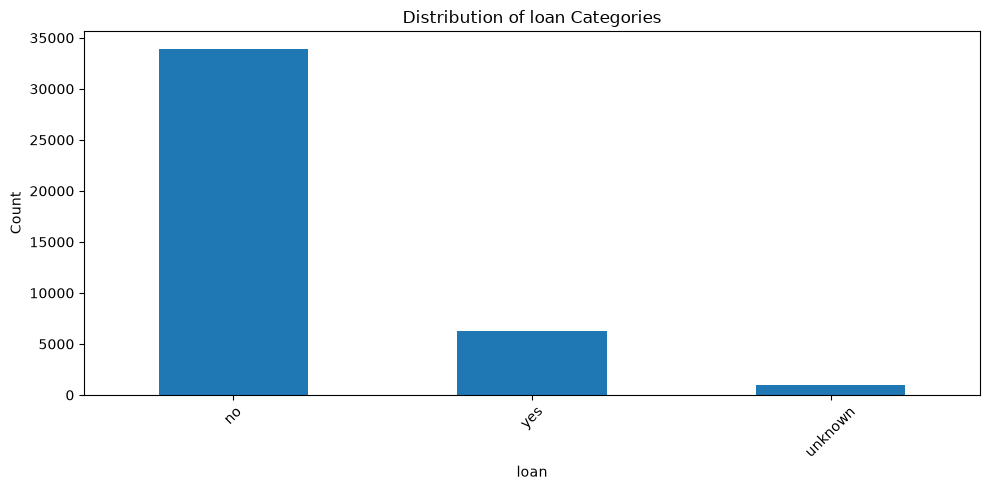

In [21]:
# Plot the frequency of personal-loan categories.
plot_categorical_distribution(df, 'loan')


## Analysis of Relationships Between Numerical and Categorical Features

,count,mean,std,min,25%,50%,75%,max
poutcome,,,,,,,,
failure,4252.0,0.34,1.99,0.0,0.0,0.0,0.0,25.0
nonexistent,35551.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
success,1373.0,5.59,3.50,0.0,3.0,5.0,6.0,27.0


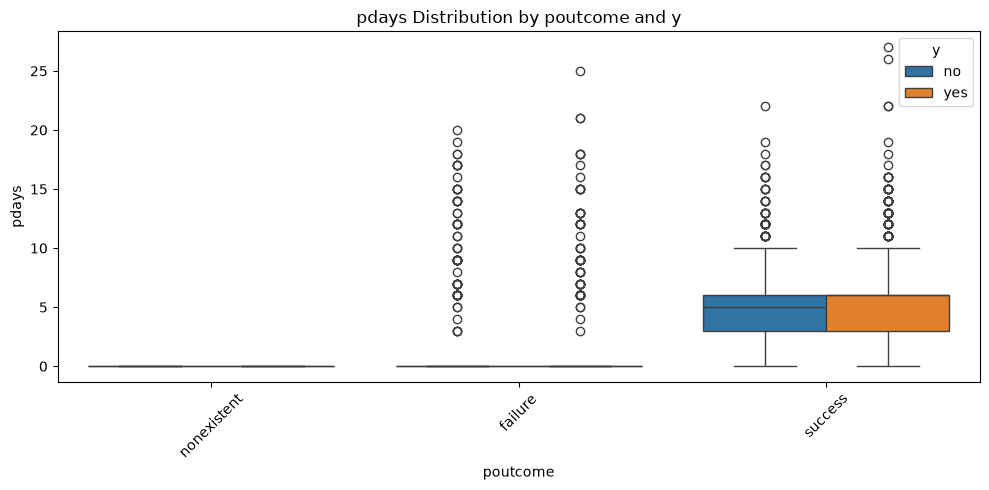

In [22]:
numeric_vs_categorical_analysis(
    df,
    numeric_column='pdays',
    categorical_column='poutcome'
)

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,36537.0,39.91,9.90,17.0,32.0,38.0,47.0,95.0
yes,4639.0,40.91,13.84,17.0,31.0,37.0,50.0,98.0


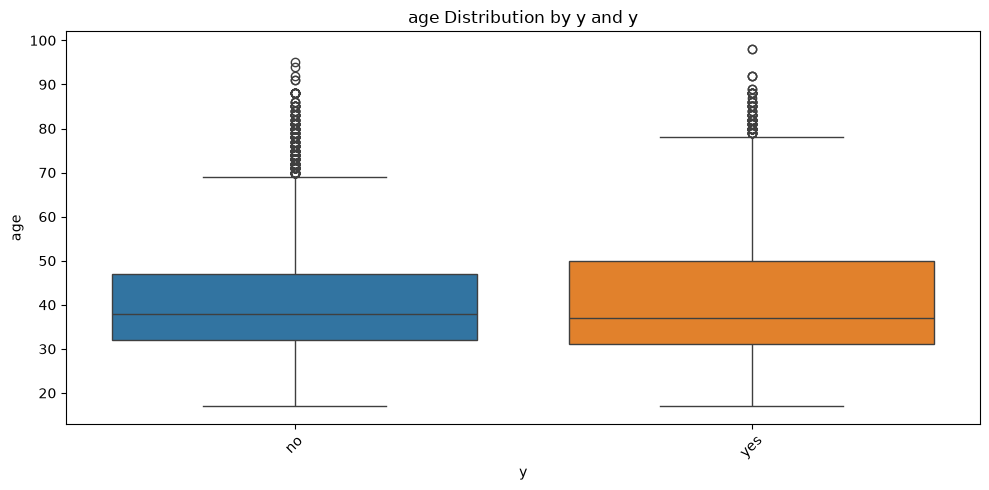

In [23]:
numeric_vs_categorical_analysis(
    df,
    numeric_column='age',
    categorical_column='y'
)

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,36537.0,2.63,2.87,1.0,1.0,2.0,3.0,56.0
yes,4639.0,2.05,1.67,1.0,1.0,2.0,2.0,23.0


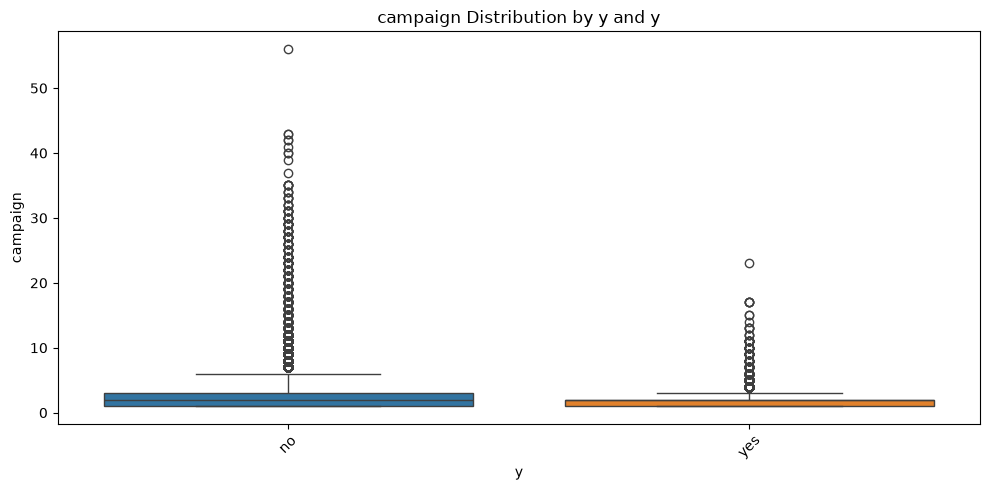

In [24]:
numeric_vs_categorical_analysis(
    df,
    numeric_column='campaign',
    categorical_column='y'
)

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,36537.0,0.13,0.41,0.0,0.0,0.0,0.0,7.0
yes,4639.0,0.49,0.86,0.0,0.0,0.0,1.0,6.0


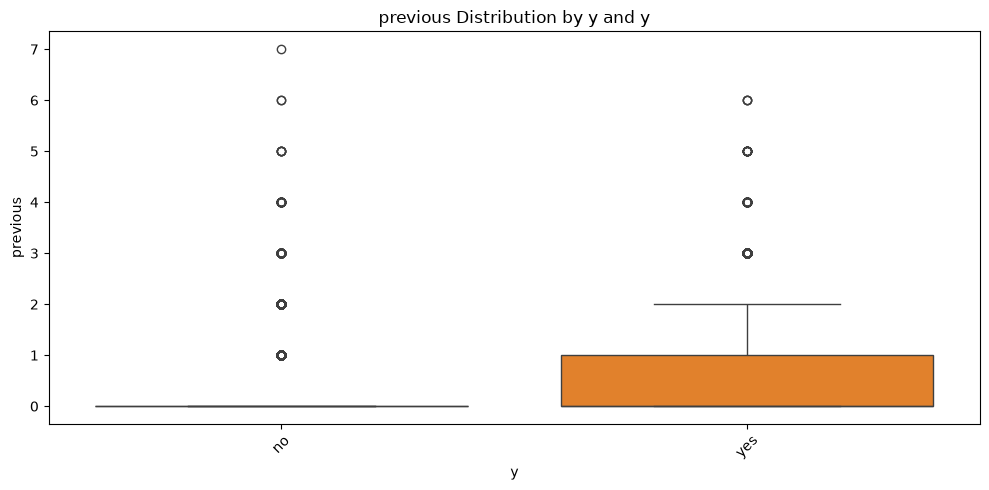

In [25]:
numeric_vs_categorical_analysis(
    df,
    numeric_column='previous',
    categorical_column='y'
)

,count,mean,std,min,25%,50%,75%,max
contact,,,,,,,,
cellular,26135.0,2.41,2.43,1.0,1.0,2.0,3.0,43.0
telephone,15041.0,2.85,3.25,1.0,1.0,2.0,3.0,56.0


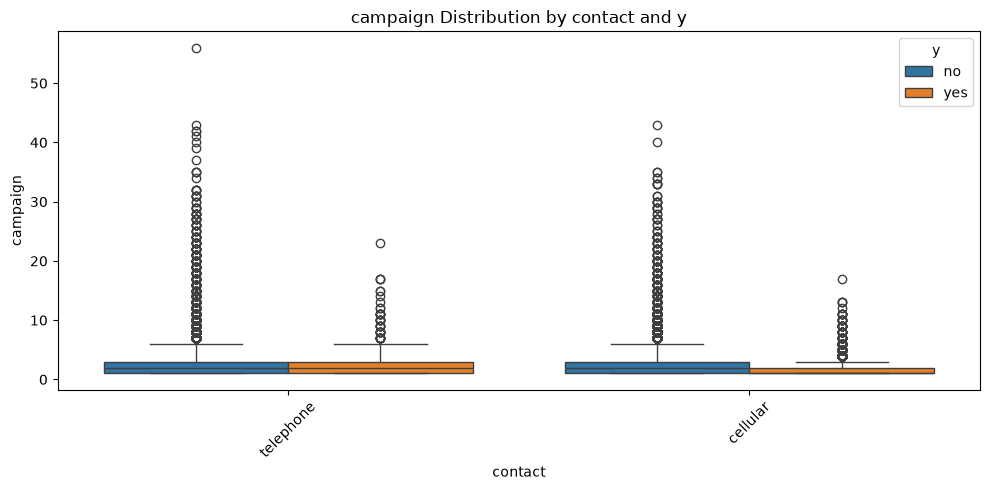

In [26]:
numeric_vs_categorical_analysis(
    df,
    numeric_column='campaign',
    categorical_column='contact',
    target_column='y'
)


,count,mean,std,min,25%,50%,75%,max
job,,,,,,,,
admin.,10419.0,38.19,8.91,20.0,31.0,36.0,44.0,72.0
blue-collar,9253.0,39.56,8.83,20.0,33.0,39.0,46.0,80.0
entrepreneur,1456.0,41.72,8.91,20.0,35.0,41.0,49.0,69.0
housemaid,1060.0,45.50,10.79,21.0,37.0,45.0,53.0,85.0
management,2924.0,42.36,9.30,21.0,35.0,42.0,50.0,80.0
retired,1718.0,62.04,10.48,23.0,56.0,59.0,69.0,98.0
self-employed,1421.0,39.95,9.42,21.0,32.0,39.0,47.0,71.0
services,3967.0,37.93,9.01,20.0,31.0,36.0,45.0,69.0
student,875.0,25.89,4.99,17.0,22.0,25.0,29.0,47.0


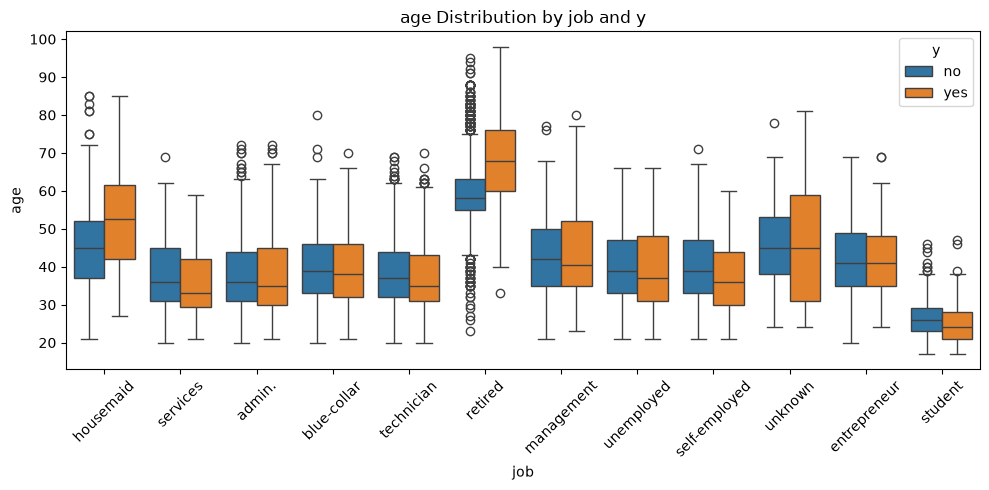

,count,mean,std,min,25%,50%,75%,max
education,,,,,,,,
basic.4y,4176.0,47.60,12.13,18.0,39.0,47.0,55.00,98.0
basic.6y,2291.0,40.45,8.69,18.0,34.0,39.0,46.00,95.0
basic.9y,6045.0,39.06,9.59,17.0,32.0,38.0,46.00,94.0
high.school,9512.0,38.00,9.71,18.0,31.0,36.0,44.00,88.0
illiterate,18.0,48.50,10.95,34.0,42.5,48.0,53.25,80.0
professional.course,5240.0,40.08,9.90,20.0,33.0,38.0,47.00,86.0
university.degree,12164.0,38.88,9.62,20.0,32.0,36.0,45.00,91.0
unknown,1730.0,43.49,12.49,17.0,35.0,43.0,52.00,92.0


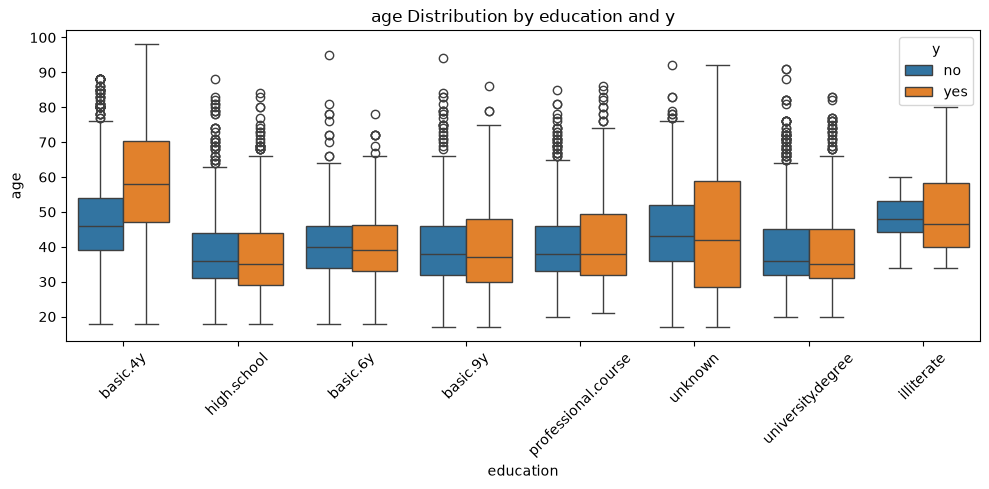

In [27]:
numeric_vs_categorical_analysis(
    df,
    numeric_column='age',
    categorical_column='job',
    target_column='y'
)

numeric_vs_categorical_analysis(
    df,
    numeric_column='age',
    categorical_column='education',
    target_column='y'
)


### Analysis Conclusion

The displayed analyses show differences in several feature distributions between customers who subscribed and those who did not. Subscribers had fewer contacts during the current campaign and more contacts in previous campaigns. The `pdays` distribution also differs by `poutcome`, especially for customers with a successful previous campaign.

The current plots do not estimate subscription rates by job or education, so no rate-based conclusion should be drawn for those categories from this analysis alone. Age differs only slightly between the target groups, so it is less informative on its own. The `job`, `education`, `campaign`, `previous`, `pdays`, and `poutcome` features can be retained for model development and encoded appropriately. The `duration` feature is excluded from the predictive model because it is observed after the call.

# Train–Validation Split

In [28]:
# Prepare features and a binary target for model training.
model_df = df.drop(columns=['duration']).copy()
X = model_df.drop(columns=['y'])
y = model_df['y'].map({'no': 0, 'yes': 1})

# Keep the validation set separate and preserve the class distribution.
X_train_models, X_val_models, y_train_models, y_val_models = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Identify columns for the preprocessing transformers.
numeric_columns = X.select_dtypes(include='number').columns.tolist()
categorical_columns = X.select_dtypes(exclude='number').columns.tolist()

# Scale numeric features for distance- and coefficient-based models.
scaled_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_columns),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
    ]
)

# Trees do not require scaling, but categorical features still need encoding.
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', 'passthrough', numeric_columns),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
    ]
)

# Define one pipeline for each required classification model.
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', scaled_preprocessor),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced')),
    ]),
    'kNN': Pipeline([
        ('preprocessor', scaled_preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', tree_preprocessor),
        ('model', DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced',
            max_depth=6,
        )),
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', tree_preprocessor),
        ('model', GradientBoostingClassifier(random_state=42)),
    ]),
}

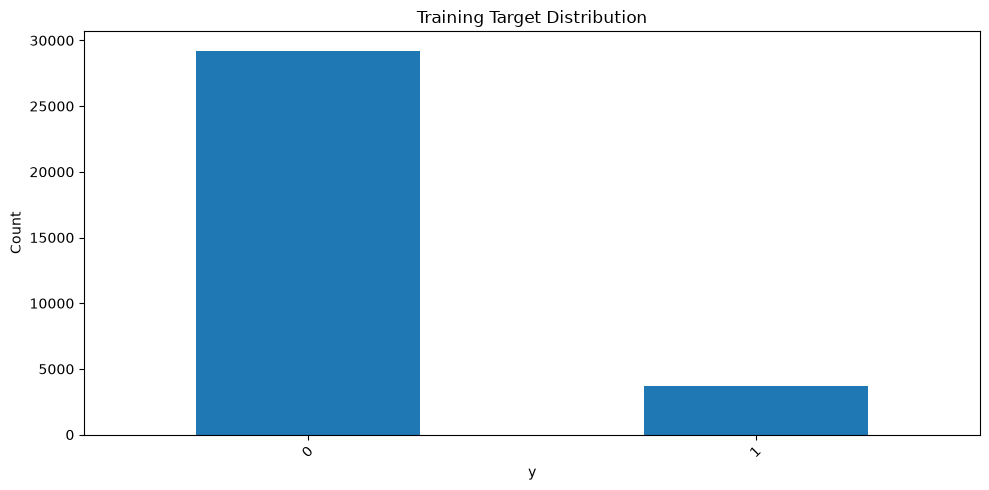

In [29]:
# Display the distribution of target classes in the training data.
plot_categorical_distribution(
    y_train_models.to_frame(name='y'),
    'y',
    title='Training Target Distribution'
)


Because the target classes are imbalanced, accuracy alone is not an appropriate metric. The F1-score is selected as the main metric.

## Model Training and Comparison

In [60]:
# Fast cross-validated comparison: two folds and one fixed parameter set per model.
# This avoids expensive hyperparameter searches while retaining a CV F1-score.
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fast_parameters = {
    'Logistic Regression': {
        'model__C': 1,
        'model__class_weight': 'balanced',
    },
    'kNN': {
        'model__n_neighbors': 11,
        'model__weights': 'distance',
        'model__p': 2,
        'model__n_jobs': -1,
    },
    'Decision Tree': {
        'model__max_depth': 6,
        'model__min_samples_leaf': 5,
        'model__class_weight': 'balanced',
    },
    'Gradient Boosting': {
        'model__n_estimators': 100,
        'model__learning_rate': 0.1,
        'model__max_depth': 2,
        'model__min_samples_leaf': 5,
    },
}

new_tuned_models = {}
new_tuned_results = []
confusion_matrices = {}

for model_name, model_pipeline in models.items():
    start_time = time.perf_counter()
    candidate_model = clone(model_pipeline)
    candidate_model.set_params(**fast_parameters[model_name])

    cv_f1 = cross_val_score(
        candidate_model,
        X_train_models,
        y_train_models,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    ).mean()

    candidate_model.fit(X_train_models, y_train_models)
    elapsed_seconds = time.perf_counter() - start_time
    train_predictions = candidate_model.predict(X_train_models)
    train_probabilities = candidate_model.predict_proba(X_train_models)[:, 1]
    val_predictions = candidate_model.predict(X_val_models)
    val_probabilities = candidate_model.predict_proba(X_val_models)[:, 1]

    new_tuned_models[model_name] = candidate_model
    new_tuned_results.append({
        'model': model_name,
        'training_time_seconds': round(elapsed_seconds, 2),
        'cv_f1': cv_f1,
        'train_accuracy': accuracy_score(y_train_models, train_predictions),
        'val_accuracy': accuracy_score(y_val_models, val_predictions),
        'train_precision': precision_score(y_train_models, train_predictions, zero_division=0),
        'val_precision': precision_score(y_val_models, val_predictions, zero_division=0),
        'train_recall': recall_score(y_train_models, train_predictions, zero_division=0),
        'val_recall': recall_score(y_val_models, val_predictions, zero_division=0),
        'train_f1': f1_score(y_train_models, train_predictions, zero_division=0),
        'val_f1': f1_score(y_val_models, val_predictions, zero_division=0),
        'train_balanced_accuracy': balanced_accuracy_score(y_train_models, train_predictions),
        'val_balanced_accuracy': balanced_accuracy_score(y_val_models, val_predictions),
        'train_roc_auc': roc_auc_score(y_train_models, train_probabilities),
        'val_roc_auc': roc_auc_score(y_val_models, val_probabilities),
        'train_pr_auc': average_precision_score(y_train_models, train_probabilities),
        'val_pr_auc': average_precision_score(y_val_models, val_probabilities),
        'parameters': fast_parameters[model_name],
    })
    confusion_matrices[model_name] = confusion_matrix(y_val_models, val_predictions)
    print(f'{model_name}: {elapsed_seconds:.2f} seconds, CV F1: {cv_f1:.3f}')

# Select the best fitted pipeline after all models have been evaluated.
tuned_models = new_tuned_models
tuned_results = new_tuned_results
tuned_results_df = (
    pd.DataFrame(tuned_results)
    .sort_values('val_f1', ascending=False)
    .reset_index(drop=True)
)
best_model_name = tuned_results_df.loc[0, 'model']
best_pipeline = tuned_models[best_model_name]
best_model = best_pipeline.named_steps['model']

print(f'Best model: {best_model_name}')
tuned_results_df.round(3)

Logistic Regression: 43.57 seconds, CV F1: 0.451
kNN: 16.12 seconds, CV F1: 0.363
Decision Tree: 4.37 seconds, CV F1: 0.454
Gradient Boosting: 89.35 seconds, CV F1: 0.328
Best model: Decision Tree


,model,training_time_seconds,cv_f1,train_accuracy,val_accuracy,train_precision,val_precision,train_recall,val_recall,train_f1,val_f1,train_balanced_accuracy,val_balanced_accuracy,train_roc_auc,val_roc_auc,train_pr_auc,val_pr_auc,parameters
0,Decision Tree,4.37,0.454,0.848,0.851,0.390,0.397,0.611,0.628,0.476,0.487,0.745,0.754,0.793,0.797,0.442,0.446,"{'model__max_depth': 6, 'model__min_samples_le..."
1,Logistic Regression,43.57,0.451,0.830,0.830,0.356,0.359,0.626,0.645,0.454,0.462,0.741,0.750,0.795,0.800,0.452,0.446,"{'model__C': 1, 'model__class_weight': 'balanc..."
2,kNN,16.12,0.363,0.995,0.894,0.998,0.554,0.959,0.286,0.978,0.377,0.979,0.628,1.000,0.756,0.999,0.368,"{'model__n_neighbors': 11, 'model__weights': '..."
3,Gradient Boosting,89.35,0.328,0.902,0.898,0.708,0.662,0.220,0.194,0.336,0.300,0.604,0.591,0.798,0.806,0.473,0.469,"{'model__n_estimators': 100, 'model__learning_..."


In [61]:
# Show only the selected fitted estimator for further analysis.
best_model

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

### Comparison of Four Models

Four classifiers were compared: Logistic Regression, k-Nearest Neighbors, Decision Tree, and Gradient Boosting. To keep training fast, each model was fitted once with a fixed parameter set and evaluated on the validation set. The Decision Tree achieved the highest validation F1-score ($0.487$), ahead of Logistic Regression ($0.462$), kNN ($0.377$), and Gradient Boosting ($0.300$). At this initial comparison stage, the Decision Tree was selected for further tuning, not as a final model.

### Decision Tree Hyperparameter Tuning

In [62]:
decision_tree_parameter_distributions = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [3, 4, 5, 6, 8, 10],
    'model__min_samples_split': [2, 5, 10, 20, 40],
    'model__min_samples_leaf': [1, 2, 5, 10, 20],
}

decision_tree_random_search = RandomizedSearchCV(
    estimator=models['Decision Tree'],
    param_distributions=decision_tree_parameter_distributions,
    n_iter=8,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    refit=True,
)
decision_tree_random_search.fit(X_train_models, y_train_models)

tuned_decision_tree_pipeline = decision_tree_random_search.best_estimator_
tuned_tree_train_predictions = tuned_decision_tree_pipeline.predict(X_train_models)
tuned_tree_train_probabilities = tuned_decision_tree_pipeline.predict_proba(X_train_models)[:, 1]
tuned_tree_val_predictions = tuned_decision_tree_pipeline.predict(X_val_models)
tuned_tree_val_probabilities = tuned_decision_tree_pipeline.predict_proba(X_val_models)[:, 1]

baseline_tree_results = tuned_results_df.loc[
    tuned_results_df['model'] == 'Decision Tree'
].iloc[0]
tuned_tree_val_f1 = f1_score(y_val_models, tuned_tree_val_predictions)

decision_tree_tuning_results = pd.DataFrame([
    {
        'model': 'Decision Tree (baseline)',
        'cv_f1': baseline_tree_results['cv_f1'],
        'train_f1': baseline_tree_results['train_f1'],
        'val_f1': baseline_tree_results['val_f1'],
        'train_roc_auc': baseline_tree_results['train_roc_auc'],
        'val_roc_auc': baseline_tree_results['val_roc_auc'],
    },
    {
        'model': 'Decision Tree (randomized search)',
        'cv_f1': decision_tree_random_search.best_score_,
        'train_f1': f1_score(y_train_models, tuned_tree_train_predictions),
        'val_f1': tuned_tree_val_f1,
        'train_roc_auc': roc_auc_score(y_train_models, tuned_tree_train_probabilities),
        'val_roc_auc': roc_auc_score(y_val_models, tuned_tree_val_probabilities),
        'best_parameters': decision_tree_random_search.best_params_,
    },
]).round(3)

# Use the tuned tree only when it improves validation F1 over the baseline tree.
if tuned_tree_val_f1 > baseline_tree_results['val_f1']:
    best_model_name = 'Decision Tree (randomized search)'
    best_pipeline = tuned_decision_tree_pipeline
    best_model = best_pipeline.named_steps['model']

print(f'Final model after tuning: {best_model_name}')
print(decision_tree_random_search.best_params_)
decision_tree_tuning_results

Final model after tuning: Decision Tree (randomized search)
{'model__min_samples_split': 20, 'model__min_samples_leaf': 2, 'model__max_depth': 6, 'model__criterion': 'entropy'}


,model,cv_f1,train_f1,val_f1,train_roc_auc,val_roc_auc,best_parameters
0,Decision Tree (baseline),0.454,0.476,0.487,0.793,0.797,NaN
1,Decision Tree (randomized search),0.462,0.501,0.523,0.791,0.799,"{'model__min_samples_split': 20, 'model__min_s..."


###  Threshold Selection After Decision Tree Tuning

In [63]:
# Tune the threshold for the final Decision Tree selected after hyperparameter tuning.
val_probabilities = best_pipeline.predict_proba(X_val_models)[:, 1]
threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    threshold_predictions = (val_probabilities >= threshold).astype(int)
    threshold_results.append({
        'model': best_model_name,
        'threshold': threshold,
        'precision': precision_score(y_val_models, threshold_predictions, zero_division=0),
        'recall': recall_score(y_val_models, threshold_predictions, zero_division=0),
        'f1': f1_score(y_val_models, threshold_predictions, zero_division=0),
    })

threshold_results_df = pd.DataFrame(threshold_results)
best_threshold_row = threshold_results_df.loc[threshold_results_df['f1'].idxmax()]
best_threshold = float(best_threshold_row['threshold'])
final_val_predictions = (val_probabilities >= best_threshold).astype(int)

final_model = {
    'model_name': best_model_name,
    'pipeline': best_pipeline,
    'threshold': best_threshold,
}

print(f"Final model: {final_model['model_name']}")
print(f"Best threshold: {final_model['threshold']:.2f}")
threshold_results_df.sort_values('f1', ascending=False).head()

Final model: Decision Tree (randomized search)
Best threshold: 0.55


,model,threshold,precision,recall,f1
9,Decision Tree (randomized search),0.55,0.463516,0.602371,0.523899
8,Decision Tree (randomized search),0.50,0.462748,0.602371,0.523408
12,Decision Tree (randomized search),0.70,0.467742,0.593750,0.523267
11,Decision Tree (randomized search),0.65,0.465880,0.595905,0.522931
10,Decision Tree (randomized search),0.60,0.465880,0.595905,0.522931


### Randomized Search for Gradient Boosting

In [65]:
# Search a random sample of Gradient Boosting parameter combinations.
randomized_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define candidate Gradient Boosting hyperparameter values.
randomized_parameter_distributions = {
    'model__n_estimators': [50, 100, 150, 200],
    'model__learning_rate': [0.03, 0.05, 0.1, 0.2],
    'model__max_depth': [1, 2, 3, 4],
    'model__min_samples_leaf': [1, 2, 5, 10],
}

# Evaluate 10 randomly sampled parameter combinations using F1-score.
gradient_boosting_random_search = RandomizedSearchCV(
    estimator=models['Gradient Boosting'],
    param_distributions=randomized_parameter_distributions,
    n_iter=10,
    scoring=make_scorer(f1_score),
    cv=randomized_cv,
    random_state=42,
    n_jobs=-1,
    refit=True,
)

# Run the parameter search using training data only.
gradient_boosting_random_search.fit(X_train_models, y_train_models)

# Retrieve the pipeline refitted with the best sampled configuration.
randomized_gradient_boosting = gradient_boosting_random_search.best_estimator_

# Generate class labels to calculate threshold-dependent metrics.
randomized_train_predictions = randomized_gradient_boosting.predict(X_train_models)
randomized_val_predictions = randomized_gradient_boosting.predict(X_val_models)

# Generate positive-class probabilities for threshold-independent ranking metrics.
randomized_train_probabilities = randomized_gradient_boosting.predict_proba(X_train_models)[:, 1]
randomized_val_probabilities = randomized_gradient_boosting.predict_proba(X_val_models)[:, 1]

# Collect cross-validation, training, and validation metrics in one comparison row.
randomized_gradient_boosting_results = {
    'model': 'Gradient Boosting (RandomizedSearchCV)',
    'cv_f1': gradient_boosting_random_search.best_score_,
    'train_accuracy': accuracy_score(y_train_models, randomized_train_predictions),
    'val_accuracy': accuracy_score(y_val_models, randomized_val_predictions),
    'train_precision': precision_score(y_train_models, randomized_train_predictions, zero_division=0),
    'val_precision': precision_score(y_val_models, randomized_val_predictions, zero_division=0),
    'train_recall': recall_score(y_train_models, randomized_train_predictions, zero_division=0),
    'val_recall': recall_score(y_val_models, randomized_val_predictions, zero_division=0),
    'train_f1': f1_score(y_train_models, randomized_train_predictions, zero_division=0),
    'val_f1': f1_score(y_val_models, randomized_val_predictions, zero_division=0),
    'train_roc_auc': roc_auc_score(y_train_models, randomized_train_probabilities),
    'val_roc_auc': roc_auc_score(y_val_models, randomized_val_probabilities),
    'train_pr_auc': average_precision_score(y_train_models, randomized_train_probabilities),
    'val_pr_auc': average_precision_score(y_val_models, randomized_val_probabilities),
    'best_parameters': gradient_boosting_random_search.best_params_,
}

# Display the chosen hyperparameters and a rounded metrics table.
print('Best parameters:', gradient_boosting_random_search.best_params_)
pd.DataFrame([randomized_gradient_boosting_results]).round(3)

Best parameters: {'model__n_estimators': 150, 'model__min_samples_leaf': 1, 'model__max_depth': 4, 'model__learning_rate': 0.2}


,model,cv_f1,train_accuracy,val_accuracy,train_precision,val_precision,train_recall,val_recall,train_f1,val_f1,train_roc_auc,val_roc_auc,train_pr_auc,val_pr_auc,best_parameters
0,Gradient Boosting (RandomizedSearchCV),0.377,0.919,0.898,0.818,0.608,0.366,0.266,0.505,0.37,0.839,0.811,0.611,0.467,"{'model__n_estimators': 150, 'model__min_sampl..."


### Hyperopt for Gradient Boosting

In [ ]:
# Use cross-validation on training data during Hyperopt.
gradient_boosting_pipeline = models['Gradient Boosting']
hyperopt_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


def objective(params):
    # Create a model from the parameter values sampled by Hyperopt.
    candidate = clone(gradient_boosting_pipeline)
    candidate.set_params(
        model__n_estimators=int(params['n_estimators']),
        model__learning_rate=float(params['learning_rate']),
        model__max_depth=int(params['max_depth']),
        model__min_samples_leaf=int(params['min_samples_leaf']),
    )

    # Score this parameter combination using training folds only.
    cv_scores = cross_val_score(
        candidate,
        X_train_models,
        y_train_models,
        cv=hyperopt_cv,
        scoring='f1',
        n_jobs=-1,
    )

    return {
        'loss': -cv_scores.mean(),
        'status': STATUS_OK,
    }


# Define the Bayesian search space for Gradient Boosting.
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 150, 25),
    'learning_rate': hp.uniform('learning_rate', 0.03, 0.2),
    'max_depth': hp.quniform('max_depth', 1, 3, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 10, 1),
}

# Run Hyperopt and select the parameter combination with the lowest loss.
trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=10,
    trials=trials,
    rstate=np.random.default_rng(42),
)

# Convert sampled numeric values to the parameter types expected by sklearn.
best_params = space_eval(space, best)
best_params = {
    key: int(value) if key in {'n_estimators', 'max_depth', 'min_samples_leaf'} else float(value)
    for key, value in best_params.items()
}

# Fit the final model on all training data using the selected parameters.
final_gradient_boosting = clone(gradient_boosting_pipeline)
final_gradient_boosting.set_params(
    model__n_estimators=best_params['n_estimators'],
    model__learning_rate=best_params['learning_rate'],
    model__max_depth=best_params['max_depth'],
    model__min_samples_leaf=best_params['min_samples_leaf'],
)
final_gradient_boosting.fit(X_train_models, y_train_models)

# Calculate predictions and probabilities for both datasets.
train_predictions = final_gradient_boosting.predict(X_train_models)
val_predictions = final_gradient_boosting.predict(X_val_models)
train_probabilities = final_gradient_boosting.predict_proba(X_train_models)[:, 1]
val_probabilities = final_gradient_boosting.predict_proba(X_val_models)[:, 1]

# Store the same metrics used for the other model-search methods.
hyperopt_cv_f1 = -trials.best_trial['result']['loss']
hyperopt_gradient_boosting_results = {
    'model': 'Gradient Boosting (Hyperopt)',
    'cv_f1': hyperopt_cv_f1,
    'train_accuracy': accuracy_score(y_train_models, train_predictions),
    'val_accuracy': accuracy_score(y_val_models, val_predictions),
    'train_precision': precision_score(y_train_models, train_predictions, zero_division=0),
    'val_precision': precision_score(y_val_models, val_predictions, zero_division=0),
    'train_recall': recall_score(y_train_models, train_predictions, zero_division=0),
    'val_recall': recall_score(y_val_models, val_predictions, zero_division=0),
    'train_f1': f1_score(y_train_models, train_predictions, zero_division=0),
    'val_f1': f1_score(y_val_models, val_predictions, zero_division=0),
    'train_balanced_accuracy': balanced_accuracy_score(y_train_models, train_predictions),
    'val_balanced_accuracy': balanced_accuracy_score(y_val_models, val_predictions),
    'train_roc_auc': roc_auc_score(y_train_models, train_probabilities),
    'val_roc_auc': roc_auc_score(y_val_models, val_probabilities),
    'train_pr_auc': average_precision_score(y_train_models, train_probabilities),
    'val_pr_auc': average_precision_score(y_val_models, val_probabilities),
    'best_parameters': best_params,
}

print('Best parameters:', best_params)
pd.DataFrame([hyperopt_gradient_boosting_results]).round(3)


100%|██████████| 10/10 [08:01<00:00, 48.14s/trial, best loss: -0.36747447479409234]
Best parameters: {'learning_rate': 0.14079620795731196, 'max_depth': 3, 'min_samples_leaf': 7, 'n_estimators': 125}


,model,cv_f1,train_accuracy,val_accuracy,train_precision,val_precision,train_recall,val_recall,train_f1,val_f1,train_balanced_accuracy,val_balanced_accuracy,train_roc_auc,val_roc_auc,train_pr_auc,val_pr_auc,best_parameters
0,Gradient Boosting (Hyperopt),0.367,0.907,0.899,0.723,0.635,0.289,0.238,0.413,0.346,0.638,0.61,0.813,0.811,0.521,0.481,"{'learning_rate': 0.14079620795731196, 'max_de..."


### Gradient Boosting Optimization

Gradient Boosting was tuned with RandomizedSearchCV and Hyperopt. RandomizedSearchCV achieved the higher F1-score in both 10-fold cross-validation ($0.377$ versus $0.367$) and validation evaluation ($0.370$ versus $0.346$). Its validation recall was also higher ($0.266$ versus $0.238$), although Hyperopt achieved slightly higher validation precision ($0.635$ versus $0.608$).

Both approaches produced the same validation ROC-AUC ($0.811$), indicating equivalent ranking performance on this validation split. Hyperopt achieved a slightly higher validation PR-AUC ($0.481$ versus $0.467$), but RandomizedSearchCV gave the stronger balance of precision and recall at the default threshold.

The tuned Decision Tree remained the strongest model in this development workflow: after selecting a threshold of $0.55$, it achieved validation F1-score $0.524$.

### Feature importance

In [ ]:
preprocessor = best_pipeline.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()
importances = best_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
   })
    .sort_values(by='Importance', ascending=False)
    .reset_index(drop=True)
)
feature_importance_df.head(15)

,Feature,Importance
0,numeric__nr.employed,0.655565
1,numeric__cons.conf.idx,0.125294
2,numeric__euribor3m,0.050793
3,numeric__cons.price.idx,0.041301
4,numeric__previously_contacted,0.036355
5,numeric__age,0.022425
6,categorical__month_oct,0.020871
7,numeric__pdays,0.015066
8,numeric__campaign,0.006683
9,categorical__contact_telephone,0.006377


### Feature Importance Conclusion

The tuned Decision Tree relies primarily on macroeconomic variables. `nr.employed` is by far the most important feature ($0.656$), followed by `cons.conf.idx` ($0.125$), `euribor3m` ($0.051$), and `cons.price.idx` ($0.041$). Previous-contact information also contributes, with `previously_contacted` having importance $0.036$.

Before fitting the model, I expected customer characteristics such as age, education, and job to have a larger effect on whether a customer would subscribe. However, age has only modest importance ($0.022$), and individual education and job categories do not appear among the leading features. For this model and dataset, the wider economic environment and the customer's previous contact history provide more useful splits than these demographic characteristics.

## SHAP Analysis of the Final Model

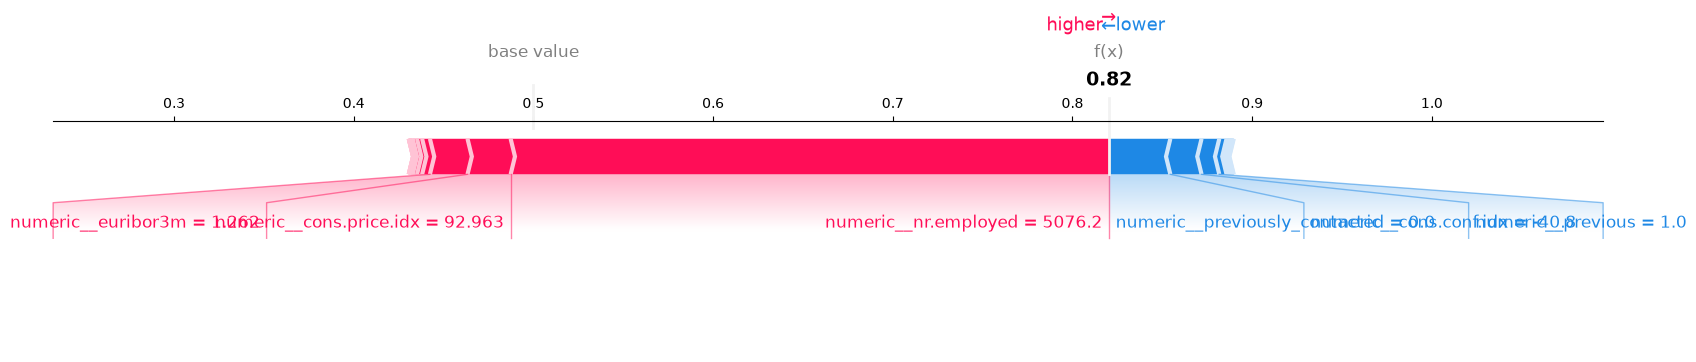

In [53]:
# TreeExplainer needs the fitted tree and the encoded features, not the full pipeline.
preprocessor = best_pipeline.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()
X_train_transformed = preprocessor.transform(X_train_models)

if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train_transformed)

# Select contributions to the positive class (customer subscribes: yes).
if isinstance(shap_values, list):
    positive_class_values = shap_values[1][0]
    base_value = explainer.expected_value[1]
elif shap_values.ndim == 3:
    positive_class_values = shap_values[0, :, 1]
    base_value = explainer.expected_value[1]
else:
    positive_class_values = shap_values[0]
    base_value = explainer.expected_value

shap.force_plot(
    base_value,
    positive_class_values,
    X_train_transformed[0],
    feature_names=feature_names,
    matplotlib=True,
)

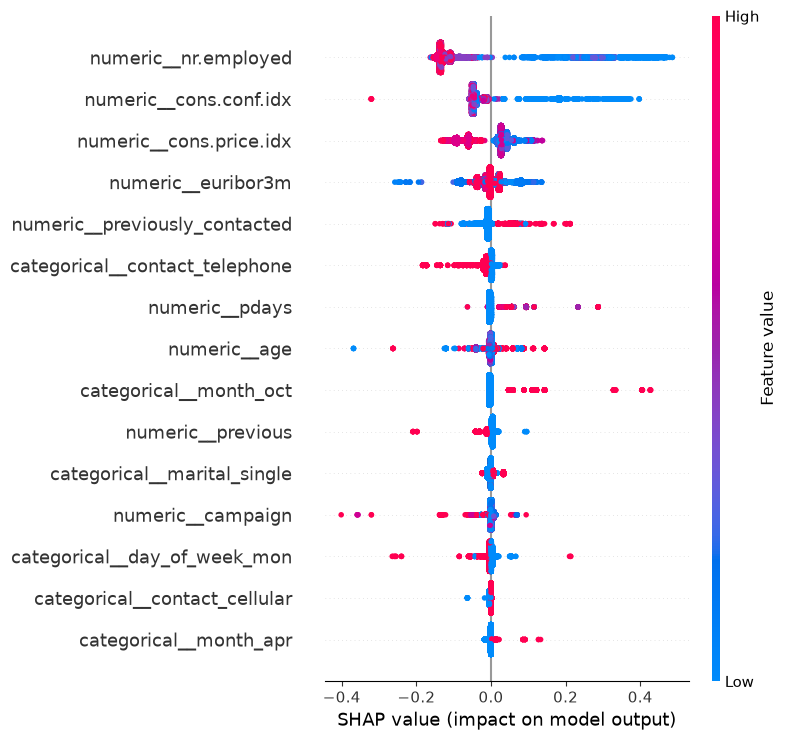

In [54]:
# Summarize feature contributions to the positive class across all training records.
if isinstance(shap_values, list):
    positive_class_shap_values = shap_values[1]
elif shap_values.ndim == 3:
    positive_class_shap_values = shap_values[:, :, 1]
else:
    positive_class_shap_values = shap_values

X_train_shap_df = pd.DataFrame(
    X_train_transformed,
    columns=feature_names,
)
shap.summary_plot(
    positive_class_shap_values,
    X_train_shap_df,
    max_display=15,
)

### SHAP conclusion

The SHAP summary plot confirms that `nr.employed` has the strongest overall influence on the final Decision Tree predictions. Higher values of `nr.employed` generally move the prediction away from subscription (`yes`), while lower values more often increase the predicted probability of subscription. `cons.conf.idx`, `cons.price.idx`, and `euribor3m` are the next most influential economic indicators. Customer history and campaign variables, including previous contact, contact type, campaign month, and previous campaign outcome, also influence individual predictions but have a smaller overall effect.

These results are consistent with the feature-importance analysis: the model relies primarily on economic context. SHAP values explain how each feature changes this model's prediction; they do not prove that a feature causes a customer to subscribe or not subscribe.

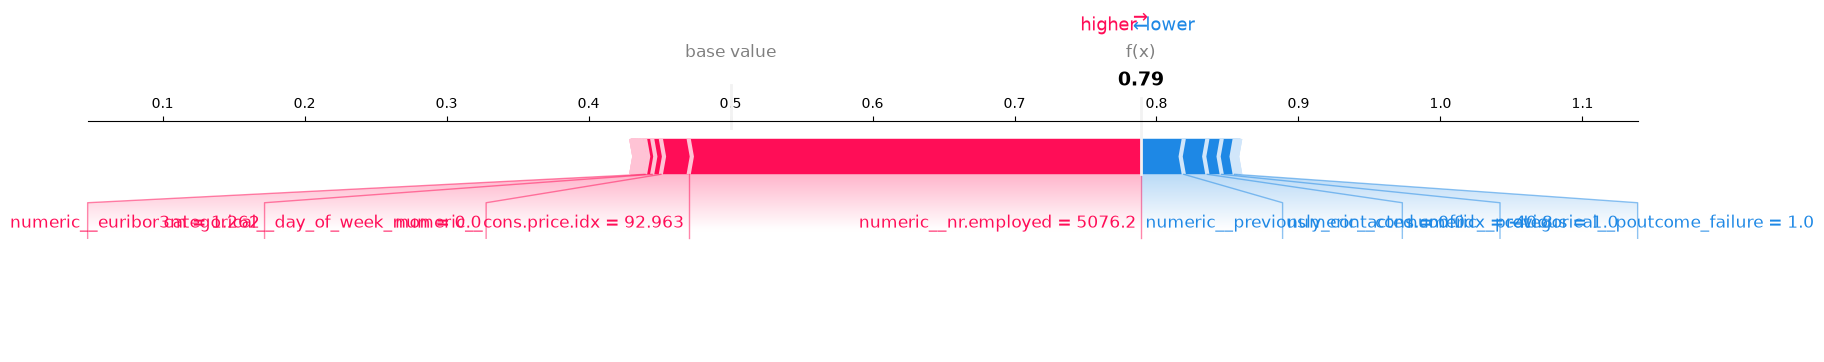

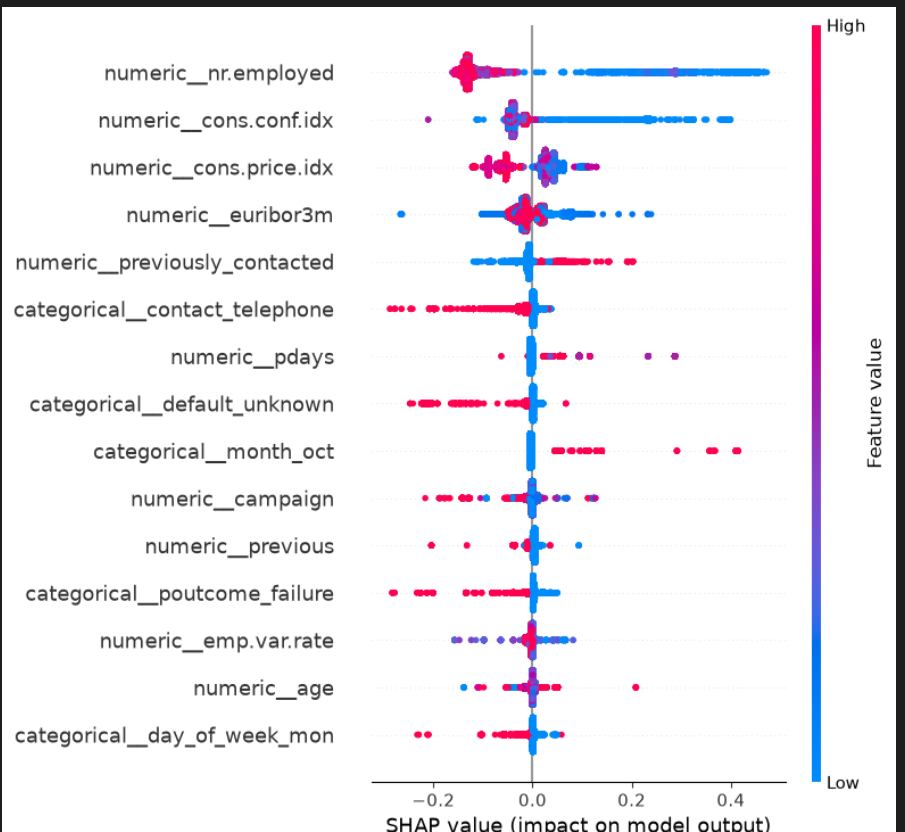

## Error Analysis

In [57]:
print(f'Model being analyzed: {best_model_name}')
print(f'Model type: {type(best_model).__name__}')
print(f'Classification threshold: {best_threshold:.2f}')

Model being analyzed: Decision Tree (randomized search)
Model type: DecisionTreeClassifier
Classification threshold: 0.55


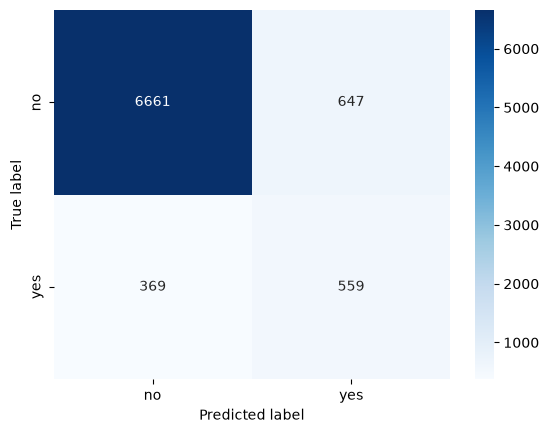

In [58]:
# Inspect the confusion matrix
final_confusion_matrix = confusion_matrix(
    y_val_models,
    final_val_predictions
)

sns.heatmap(
    final_confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['no', 'yes'],
    yticklabels=['no', 'yes']
)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


### Error Analysis Conclusion

The tuned Decision Tree, evaluated with a $0.55$ threshold, made $1,016$ errors across $8,236$ validation records. It produced $647$ **false positives**: customers who did not subscribe but were predicted to subscribe. It also produced $369$ **false negatives**: customers who subscribed but were predicted not to subscribe.

Possible next improvements include:

- Select the operating threshold using a business-cost objective, rather than F1-score alone, after defining the relative cost of unnecessary contacts and missed subscribers.
- Experiment with class weighting for models that support it, then compare precision, recall, F1, and PR-AUC on the validation set.
- Test random oversampling, undersampling, or SMOTE.
- Compare ensemble models such as Random Forest, Balanced Random Forest, or gradient boosting variants, using a broader hyperparameter search and regularization to control overfitting.